In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE
from itertools import product as iproduct
from sklearn.metrics import f1_score, accuracy_score

In [2]:
FILES = ["S07main_EpochedNoseRefCleanTimesFixed.mat"]
TOTAL_TIMES = 1229

In [3]:
#method to extract data from mat file
def get_field(struct, name):
    f = struct[name]
    if f.dtype == object:
        out = []
        for item in f.flatten():
            if isinstance(item, np.ndarray):
                out.append(item[0,0] if item.size==1 and item.ndim>1 else (item[0] if item.size==1 else item))
            else:
                out.append(item)
        return out
    return f.flatten() if f.size > 1 else f[0,0]

def load_files(files):
    vals, trials = [], []
    for f in files:
        dc = loadmat(f)["dataClean"][0,0]
        t  = np.array(get_field(dc, "trial"))
        ti = np.array(get_field(dc, "trialinfo")).reshape(len(t), 5)
        v  = ti[:, 1]
        vals.extend(v); trials.extend(t)
    trials = np.array(trials); vals = np.array(vals)
    mask   = (vals != -1) & (vals != 0)
    return vals[mask] - 1, trials[mask]   # labels {0,1}, trials

In [4]:
y, all_trials = load_files(FILES)
X_full = all_trials.transpose(0, 2, 1)   # (trials, timesteps, channels)
print(f"Trials: {len(y)}  |  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")

#split the data
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

#normalise the data
mean = X_tr_raw.mean(axis=(0,1), keepdims=True)
std  = X_tr_raw.std(axis=(0,1),  keepdims=True) + 1e-6
X_train = (X_tr_raw  - mean) / std
X_test  = (X_te_raw  - mean) / std
print(f"Train/Test: {len(y_train)}/{len(y_test)}")


Trials: 222  |  Class 0: 134  Class 1: 88
Train/Test: 177/45


In [5]:
#results showing methof
def show_results(name, y_true, y_pred):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["Class 0","Class 1"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Class 0","Class 1"], yticklabels=["Class 0","Class 1"])
    plt.title(name); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

In [6]:
#defining LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return torch.sigmoid(self.fc(self.drop(out[:, -1, :])))

#training LSTM model
def train_lstm(X, y_lbl, epochs=30, batch_size=32, lr=1e-3):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y_lbl, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    model   = LSTMModel(X.shape[2]).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb).squeeze(), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

def predict_lstm(model, X):
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    return (p > 0.5).astype(int)

Grid search over 28 combinations...
   #     Acc      F1    Bias  Params
----------------------------------------------------------------------
[  1/28]  0.4722  0.4618  0.5278  {'hidden': 2, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  2/28]  0.6389  0.5847  0.3056  {'hidden': 2, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}
[  3/28]  0.6389  0.4526  0.0833  {'hidden': 2, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  4/28]  0.6667  0.4000  0.0000  {'hidden': 2, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}
[  5/28]  0.5833  0.5209  0.3056  {'hidden': 4, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  6/28]  0.6944  0.6303  0.2500  {'hidden': 4, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}
[  7/28]  0.6667  0.6250  0.3333  {'hidden': 4, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 16}
[  8/28]  0.6389  0.3898  0.0278  {'hidden': 4, 'layers': 2, 'dropout': 0.0, 'lr': 0.001, 'batch_siz

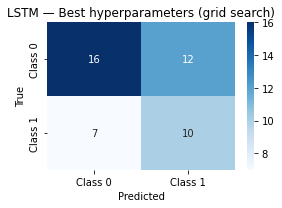

In [8]:
#converted norml model training section into grid search
#Use 20% of training data for a validation set (no data leakage from test set)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0)

#grid search config (i didn't check dropout or lr combinations because it would take too long)
param_grid = {
    'hidden':     [2, 4, 6, 16, 32, 64, 128],
    'layers':     [1, 2],
    'dropout':    [0.0],
    'lr':         [1e-3],
    'batch_size': [16, 32],
}

def train_lstm_hp(X, y_lbl, hidden, layers, dropout, lr, batch_size, epochs=30):
    """Like train_lstm but exposes all hyperparameters."""
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y_lbl, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    model   = LSTMModel(X.shape[2], hidden=hidden, layers=layers, dropout=dropout).to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb).squeeze(), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

keys   = list(param_grid.keys())
combos = list(iproduct(*param_grid.values()))
print(f"Grid search over {len(combos)} combinations...")
print(f"{'#':>4}  {'Acc':>6}  {'F1':>6}  {'Bias':>6}  Params")
print("-" * 70)

best_f1, best_params, results = -1, None, []

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    model  = train_lstm_hp(X_tr2, y_tr2, **params)
    preds  = predict_lstm(model, X_val)
    f1     = f1_score(y_val, preds, average='macro', zero_division=0)
    acc    = accuracy_score(y_val, preds)
    #bias is the proportion of predictions that are class 1 (0.5 = balanced)
    bias   = preds.mean()
    results.append({'params': params, 'f1': f1, 'acc': acc, 'bias': bias})
    print(f"[{i+1:>3}/{len(combos)}]  {acc:.4f}  {f1:.4f}  {bias:.4f}  {params}")
    if f1 > best_f1:
        best_f1, best_params = f1, params

#summary of contents
print(f"\n{'='*70}")
print("Top 5 combinations by macro-F1:")
print(f"{'Acc':>6}  {'F1':>6}  {'Bias':>6}  Params")
print("-" * 60)
for r in sorted(results, key=lambda x: x['f1'], reverse=True)[:5]:
    print(f"{r['acc']:.4f}  {r['f1']:.4f}  {r['bias']:.4f}  {r['params']}")
print(f"{'='*70}")

#Use normal training / test split and train a model using best hyperparameters
print("\nRe-training best config on full training set...")
best_model = train_lstm_hp(X_train, y_train, **best_params)
show_results("LSTM — Best hyperparameters (grid search)", y_test, predict_lstm(best_model, X_test))
